## Part 5 WaveNet
WaveNet Paper: https://arxiv.org/abs/1609.03499

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [5]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [6]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


In [28]:
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []
  
class Embedding:
  def __init__(self, num_embedding, embedding_dim):
    self.weight = torch.randn((num_embedding, embedding_dim))
  
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
  
  def parameters(self):
    return [self.weight]

class FlattenConsecutive:
  def __init__(self, n):
    self.n = n ## this is the desired size of each small blocks 
  
  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T // self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out
  
  def parameters(self):
    return []
    
class Sequential:
  def __init__(self, layers):
    self.layers = layers
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [29]:
torch.manual_seed(42)

In [32]:
n_embd = 24
n_hidden = 128
# C = torch.randn((vocab_size, n_embd))
model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

76579


In [33]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    ix = torch.randint(0, Xtr.shape[0], (batch_size,)) ## this has replacement may not be a good choice
    Xb, Yb = Xtr[ix], Ytr[ix]

    ## forward path
    # emb = C[Xb]
    # x = emb.view(emb.shape[0], -1) ## reshape as (block_size*n_embd, )
    # x = Xb
    # for layer in layers:
    #     x = layer(x) ## output a logit value
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    ## backward path
    for p in parameters:
        p.grad = None
    loss.backward()

    # update using SGD
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr*p.grad

    if i % 10000 == 0:
        print(f"Step {i}, Loss: {loss.item()}")
    
    lossi.append(loss.log10().item())
    # break


Step 0, Loss: 3.299741744995117
Step 10000, Loss: 2.0582170486450195
Step 20000, Loss: 1.8734534978866577
Step 30000, Loss: 1.7900134325027466
Step 40000, Loss: 1.7455475330352783
Step 50000, Loss: 1.6731696128845215
Step 60000, Loss: 2.0513486862182617
Step 70000, Loss: 2.3072564601898193
Step 80000, Loss: 2.13879656791687
Step 90000, Loss: 1.6032134294509888
Step 100000, Loss: 1.739631175994873
Step 110000, Loss: 1.6768183708190918
Step 120000, Loss: 2.337306261062622
Step 130000, Loss: 1.8353819847106934
Step 140000, Loss: 1.521539330482483
Step 150000, Loss: 1.7770732641220093
Step 160000, Loss: 1.7128132581710815
Step 170000, Loss: 1.9049609899520874
Step 180000, Loss: 1.7410898208618164
Step 190000, Loss: 1.8602302074432373


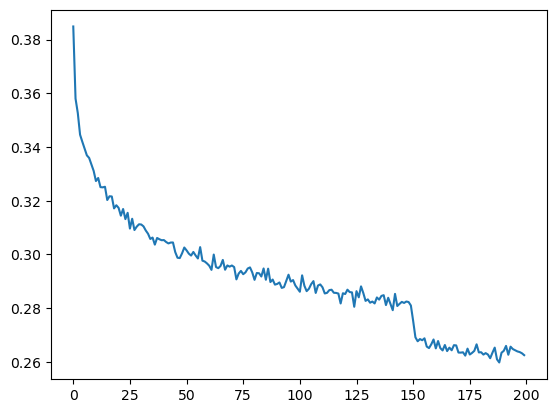

In [34]:
plt.plot(torch.tensor(lossi).view(200, -1).mean(1))

In [35]:
for layer in model.layers:
    layer.training = False

In [36]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.8026666641235352
val 1.9858930110931396


### performance log
- context block size is 8
- train loss 1.91 val loss is 2.03

In [37]:
# C = torch.randn((vocab_size, n_embd))
for _ in range(20):

    out = []
    context = [0] * block_size ## start with ...

    while True:
        logits = model(torch.tensor([context]))
        # emb = C[(1, block_size, n_embd)] ## (1, block_size, n_embd)
        # x = emb.view(emb.shape[0], -1)
        # for layer in layers:
        #     x = layer(x)
        # logits = x
        probs = F.softmax(logits, dim = 1)
        ix = torch.multinomial(probs, num_samples = 1).item()

        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break ## end with '.'

    print(''.join(itos[i] for i in out))


kailen.
kinnleigh.
rafdyn.
carlenne.
mejod.
mileh.
tana.
leilor.
sennell.
saddie.
azay.
tariel.
hazlan.
aulania.
anwion.
clari.
journew.
maycie.
koontos.
curson.
